## SHAP comparison poster figure (RF / MLP / XGBoost)

Builds a poster figure comparing SHAP feature importance across the three models
(Random Forest, MLP, XGBoost) for the combined_all feature set. It computes the
geometric vs RAC share of total mean(|SHAP|) for each model across the three splits
(random, topology, metal), prints it as a table, and renders the poster bar chart.

SHAP importances are read from the precomputed per-model outputs:
results/rf/shap/shap_importances.csv for RF, and the cached
results/{mlp,xgb}/shap/combined_all__{split}.npz files for MLP and XGBoost. The
figure is saved as a high-DPI PNG to results/model-comparison-outliers/poster/.

Runs in the mof_mlp environment (Python 3.11): numpy, pandas, matplotlib.


In [1]:
import pathlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

ROOT = pathlib.Path('..').resolve()
OUT_DIR = ROOT / 'results' / 'model-comparison-outliers' / 'poster'
OUT_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ['rf', 'mlp', 'xgb']
MODEL_LABEL = {'rf': 'RF', 'mlp': 'MLP', 'xgb': 'XGB'}
MODEL_FULL = {'rf': 'Random Forest', 'mlp': 'MLP', 'xgb': 'XGBoost'}
MODEL_COLOR = {'rf': '#1E3A5F', 'mlp': '#5B3D8C', 'xgb': '#2E7D7D'}
SPLIT_COLOR = {'random': '#4F6F8F', 'topology': '#6FA8C8', 'metal': '#B49AD6'}

# Poster styling.  Bigger fonts, soft background, lighter spines/grid.
plt.rcParams.update({
    'figure.dpi': 160, 'savefig.dpi': 300,
    'figure.facecolor': 'white', 'axes.facecolor': '#FAFAFB',
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.titlesize': 13, 'axes.titleweight': 'semibold', 'axes.titlepad': 14,
    'axes.labelsize': 11, 'axes.labelweight': 'regular', 'axes.labelpad': 8,
    'axes.edgecolor': '#666', 'axes.linewidth': 0.9,
    'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'xtick.color': '#333', 'ytick.color': '#333',
    'legend.fontsize': 10, 'legend.frameon': False,
    'grid.color': '#D8D8DC', 'grid.linewidth': 0.7, 'grid.linestyle': '-',
})
print('Output dir:', OUT_DIR)

Output dir: /Users/hannah/Desktop/ethz/Semester6/dc-mof-project/results/model-comparison-outliers/poster


In [2]:
SPLITS = ['random', 'topology', 'metal']

def geo_rac_totals(model, split):
    """Sum mean(|SHAP|) over geo features and RAC features for one (model, split)."""
    if model == 'rf':
        df = pd.read_csv(ROOT / 'results' / 'rf' / 'shap' / 'shap_importances.csv')
        sub = df[(df['feature_set'] == 'combined_all') & (df['split'] == split)]
        totals = sub.groupby('feature_type')['mean_abs_shap'].sum()
    else:
        npz = np.load(ROOT / 'results' / model / 'shap' / f'combined_all__{split}.npz',
                      allow_pickle=True)
        mean_abs = np.abs(npz['shap_values']).mean(axis=0)
        feat_names = [str(f) for f in npz['feature_names']]
        is_rac = np.array([n.startswith('racs_') for n in feat_names])
        totals = pd.Series({'geo': mean_abs[~is_rac].sum(), 'rac': mean_abs[is_rac].sum()})
    return totals


rows = []
for m in MODELS:
    for sp in SPLITS:
        t = geo_rac_totals(m, sp)
        total = t.sum()
        rows.append({'model': m, 'split': sp,
                     'geo_sum': t['geo'], 'rac_sum': t['rac'],
                     'geo_pct': 100 * t['geo'] / total,
                     'rac_pct': 100 * t['rac'] / total})
tbl = pd.DataFrame(rows)
print('Geo vs RAC SHAP share (combined_all):')
print(tbl.round(2).to_string(index=False))

Geo vs RAC SHAP share (combined_all):
model    split  geo_sum  rac_sum  geo_pct  rac_pct
   rf   random     0.74     0.26    73.86    26.14
   rf topology     0.89     0.29    75.11    24.89
   rf    metal     0.73     0.28    72.25    27.75
  mlp   random     1.64     1.70    49.14    50.86
  mlp topology     2.31     2.65    46.58    53.42
  mlp    metal     1.47     1.83    44.59    55.41
  xgb   random     1.41     0.42    77.17    22.83
  xgb topology     1.44     0.45    76.26    23.74
  xgb    metal     1.38     0.51    72.99    27.01


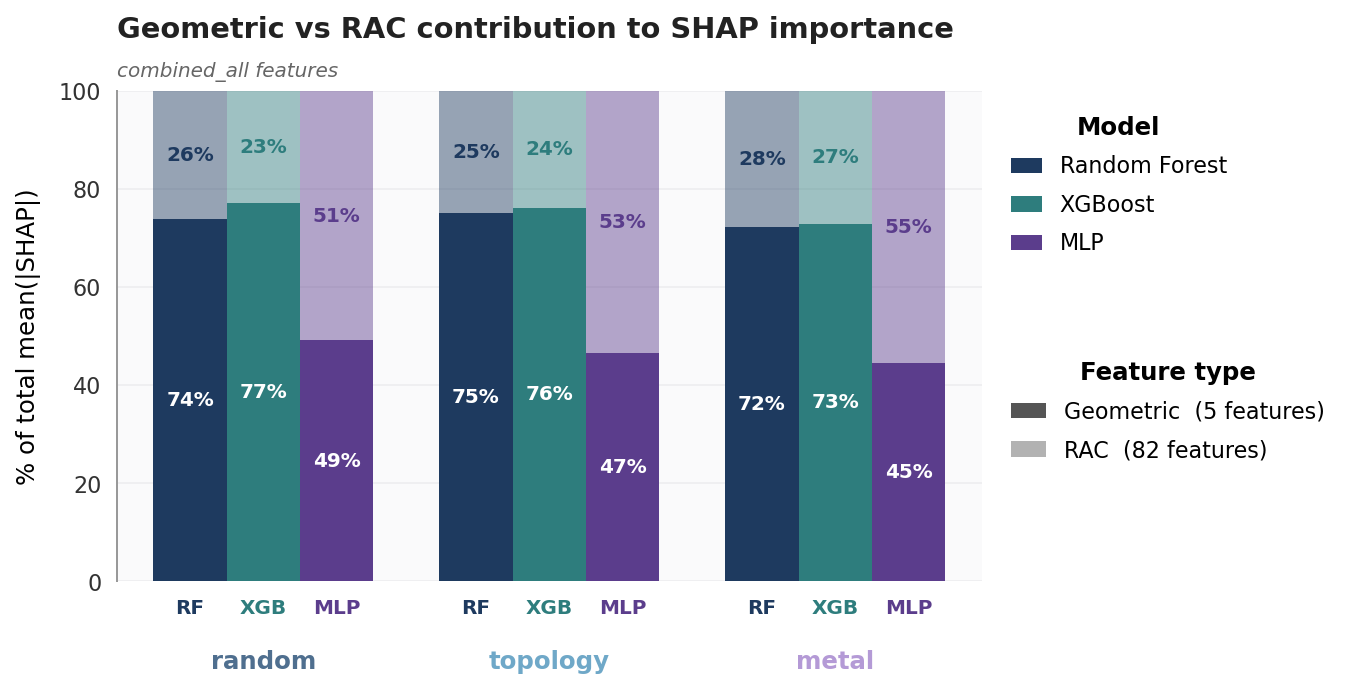

In [3]:
import matplotlib.patches as mpatches

# Alpha encoding for geo vs RAC.
#   Geo: full opacity (deep)
#   RAC: same hue, ~45% alpha (washed out)
# No outlines around bars
ALPHA_GEO = 1.00
ALPHA_RAC = 0.45

# Per-plot model order (overrides the global MODELS list for this figure only)
MODELS_ORDER = ['rf', 'xgb', 'mlp']

fig, ax = plt.subplots(figsize=(8.6, 4.5))

bar_w = 0.78
group_w = 3 * bar_w + 0.7

for gi, sp in enumerate(SPLITS):
    base = gi * group_w
    for mi, m in enumerate(MODELS_ORDER):
        row = tbl[(tbl['model'] == m) & (tbl['split'] == sp)].iloc[0]
        x = base + mi * bar_w
        color = MODEL_COLOR[m]

        # Geo segment (bottom): full opacity
        ax.bar(x, row['geo_pct'], width=bar_w,
               color=color, alpha=ALPHA_GEO,
               edgecolor='none', linewidth=0, zorder=2)
        # RAC segment (top): same colour, ~45% alpha
        ax.bar(x, row['rac_pct'], width=bar_w, bottom=row['geo_pct'],
               color=color, alpha=ALPHA_RAC,
               edgecolor='none', linewidth=0, zorder=2)

        if row['geo_pct'] >= 18:
            ax.text(x, row['geo_pct'] / 2, f"{row['geo_pct']:.0f}%",
                    ha='center', va='center', color='white',
                    fontsize=9, fontweight='semibold', zorder=5)
        if row['rac_pct'] >= 18:
            # Darker text on the washed-out RAC fill so it stays legible
            ax.text(x, row['geo_pct'] + row['rac_pct'] / 2, f"{row['rac_pct']:.0f}%",
                    ha='center', va='center', color=color,
                    fontsize=9, fontweight='semibold', zorder=5)

        ax.text(x, -3.5, MODEL_LABEL[m],
                ha='center', va='top', fontsize=9, color=MODEL_COLOR[m],
                fontweight='semibold')

    ax.text(base + bar_w, -14, sp,
            ha='center', va='top', fontsize=11,
            color=SPLIT_COLOR[sp], fontweight='semibold')

ax.set_xticks([])
ax.set_xlim(-bar_w, len(SPLITS) * group_w - 0.7)
ax.set_ylim(0, 100)
ax.set_ylabel('% of total mean(|SHAP|)')

ax.set_title('Geometric vs RAC contribution to SHAP importance',
             loc='left', color='#222', pad=24)
ax.text(0, 1.02,
        'combined_all features',
        transform=ax.transAxes, fontsize=9, color='#666', style='italic',
        ha='left', va='bottom')

# Two-part legend: model colour swatches + alpha-step key (neutral grey swatches)
model_handles = [mpatches.Patch(facecolor=MODEL_COLOR[m], edgecolor='none',
                                label=MODEL_FULL[m]) for m in MODELS_ORDER]
alpha_handles = [
    mpatches.Patch(facecolor='#555', alpha=ALPHA_GEO, edgecolor='none',
                   label='Geometric  (5 features)'),
    mpatches.Patch(facecolor='#555', alpha=ALPHA_RAC, edgecolor='none',
                   label='RAC  (82 features)'),
]

leg1 = ax.legend(handles=model_handles, loc='upper left',
                 bbox_to_anchor=(1.005, 1.0), title='Model',
                 handlelength=1.4, borderpad=0.6, labelspacing=0.7)
leg1.get_title().set_fontweight('semibold')
ax.add_artist(leg1)
leg2 = ax.legend(handles=alpha_handles, loc='upper left',
                 bbox_to_anchor=(1.005, 0.5), title='Feature type',
                 handlelength=1.6, borderpad=0.6, labelspacing=0.7)
leg2.get_title().set_fontweight('semibold')

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#999')
ax.spines['bottom'].set_visible(False)
ax.tick_params(left=False, bottom=False)
ax.grid(axis='y', alpha=0.4, zorder=0)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig(OUT_DIR / 'shap_poster_geo_rac_share.png', bbox_inches='tight')
plt.show()